In [1]:
#https://cloud.tencent.com/developer/article/2162241
###   找不到o3臭氧
###   找不到o3臭氧
###   找不到o3臭氧
###   找不到o3臭氧
###   找不到o3臭氧
###   找不到o3臭氧
###   找不到o3臭氧

In [2]:
import numpy as np    
import xarray as xr   
from netCDF4 import Dataset
from wrf import to_np, getvar, get_cartopy, cartopy_xlim,cartopy_ylim, latlon_coords,interpz3d,destagger

import matplotlib as mpl
import matplotlib.pyplot as plt  
from matplotlib.cm import get_cmap
from matplotlib.colors import ListedColormap  
import cartopy.crs as ccrs       
import cartopy.feature as cfeature 
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter, LatitudeLocator, LongitudeLocator)
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.axes import Axes
from cartopy.mpl.geoaxes import GeoAxes
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from matplotlib import ticker as mticker
import cmaps

def mapart(ax): 
    ax.coastlines('50m', color='k', lw=0.3)                
    ax.set_xlim(cartopy_xlim(o3))
    ax.set_ylim(cartopy_ylim(o3))
    ax.set_yticks([])

title='O3 concentrations above surface'
rowlabels=[ '10km','5km', '3km','1km']      

#------------------------------------------------------
ncfile = Dataset("E:/000_FuJian/wrfout_FuJian/C6_mp6_cu14/c6_d02.nc")


ph=getvar(ncfile, "PH",timeidx=0)[:,10:140,10:140]
phb=getvar(ncfile, "PHB",timeidx=0)[:,10:140,10:140]
hgt=getvar(ncfile, "HGT",timeidx=0)[10:140,10:140]
o3 = getvar(ncfile, "o3",timeidx=0)[:,10:140,10:140]

P=ph+phb
P = destagger(P,0,meta=True)
gmp=P/9.81-hgt

z_list=[10000.,5000.,3000.,1000.] #unit:m

o3_z = interpz3d(o3,gmp,np.array(z_list))
#--------------------------------------------------------

lats, lons = latlon_coords(o3)
cart_proj = get_cartopy(o3)

fig,ax=plt.subplots(4,1,figsize=(6,6),dpi=300,subplot_kw={'projection': cart_proj})

for i in range(len(z_list)):
    
    mapart(ax[i]) 
    ac0=ax[i].contourf(to_np(lons), to_np(lats), 1000.0*to_np(o3_z[i]), levels=np.arange(12,54,3),
             transform=ccrs.PlateCarree(),
             cmap=cmaps.BlGrYeOrReVi200,extend='both')
    
    ax[i].set_ylabel(rowlabels[i],size=10)     
 
plt.suptitle(title,fontsize='small',fontweight='heavy')
plt.savefig('test.png')
plt.show()

ValueError: 'o3' is not a valid variable name

In [3]:
from wrf import uvmet, to_np, getvar, interplevel, smooth2d, get_cartopy, cartopy_xlim, cartopy_ylim, latlon_coords,destagger
import numpy as np
from netCDF4 import Dataset
import metpy.calc as mpcalc
import xarray as xr
from metpy.units import units
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import from_levels_and_colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cmaps
from glob import glob
import metpy.calc as mpcalc
import metpy.constants as constants
# 打开wrfout文件  
ncfile = Dataset("E:/000_FuJian/wrfout_FuJian/C6_mp6_cu14/c6_d02.nc")

# 提取温度和气压
t = getvar(ncfile, "T")
p = getvar(ncfile, "pressure") 
qvor = getvar(ncfile,"QVAPOR")
z = getvar(ncfile,"z")
# 计算密度
rho = mpcalc.density(p, t, qvor) 

# 提取U和V
u = getvar(ncfile, "U")
v = getvar(ncfile, "V")

# 计算风速和风向
ws = getvar(ncfile, "wspd_wdir", units="m s-1")[0]

# 计算风能密度
we = 0.5 * rho * ws**3

print("风能密度:", we)

D:\miniconda3\envs\py39\lib\site-packages\pint\facets\plain\quantity.py:1006: RuntimeWarning: divide by zero encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


风能密度: <xarray.DataArray (bottom_top: 34, south_north: 207, west_east: 267)> Size: 8MB
<Quantity([[[-4.20995331e+02 -2.52195465e+02 -2.55269806e+02 ... -8.39504219e+04
   -8.15838828e+04 -7.93822109e+04]
  [-2.69745941e+02 -2.83730164e+02 -4.29204651e+02 ... -8.49586719e+04
   -8.27081953e+04 -8.06630078e+04]
  [-2.34046021e+02 -3.55888641e+02 -1.09896216e+03 ... -8.58681719e+04
   -8.37261172e+04 -8.18153672e+04]
  ...
  [-4.46067657e+01 -1.21626129e+02 -1.14179428e+02 ... -3.11350928e+03
   -3.11651929e+03 -3.13089917e+03]
  [-4.09120369e+01 -4.58651390e+01 -5.43243027e+01 ... -3.01906226e+03
   -3.02001709e+03 -3.03111865e+03]
  [-4.65610352e+01 -4.25382385e+01 -4.46317558e+01 ... -2.94843823e+03
   -2.94748633e+03 -2.95461670e+03]]

 [[-7.13665283e+02 -2.94740143e+02 -3.05285767e+02 ... -1.10700984e+05
   -1.07943812e+05 -1.05445820e+05]
  [-3.82743835e+02 -3.73115295e+02 -5.52128235e+02 ... -1.12598055e+05
   -1.10007438e+05 -1.07727164e+05]
  [-2.98457397e+02 -5.91912415e+02 -1.91

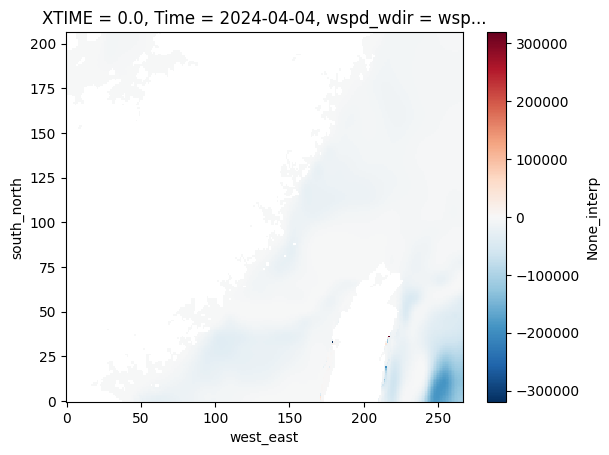

In [4]:
we100 = interplevel(we,z,100)
we100.plot()

In [5]:
ph = getvar(ncfile, "PH")
phb = getvar(ncfile, "PHB")
hgt = getvar(ncfile, "HGT")

P=ph+phb
P = destagger(P,0,meta=True)
gmp=P/9.81-hgt

we1 = interplevel(we, gmp ,100)
we1

<xarray.DataArray 'None_interp' (south_north: 207, west_east: 267)> Size: 221kB
array([[-8.71666504e+02, -3.35534180e+02, -3.43429108e+02, ...,
        -1.14668602e+05, -1.11926117e+05, -1.09458852e+05],
       [-4.44196716e+02, -4.36479828e+02, -6.60678406e+02, ...,
        -1.16695055e+05, -1.14131867e+05, -1.11895242e+05],
       [-3.56466736e+02, -7.14962769e+02, -2.19714355e+03, ...,
        -1.18557211e+05, -1.16179133e+05, -1.14156273e+05],
       ...,
       [-6.89820023e+01, -1.63936386e+02, -2.10118713e+02, ...,
        -3.81326294e+03, -3.82342041e+03, -3.84334766e+03],
       [-4.40224648e+01, -4.95111198e+01, -5.97477608e+01, ...,
        -3.70459253e+03, -3.71196826e+03, -3.72709619e+03],
       [-5.39698906e+01, -4.75726662e+01, -4.73574905e+01, ...,
        -3.62431812e+03, -3.62881226e+03, -3.63818628e+03]], dtype=float32)
Coordinates:
    XLONG      (south_north, west_east) float32 221kB 115.3 115.3 ... 123.3
    XLAT       (south_north, west_east) float32 221kB 23.17 23.17 ... 28.72
    XTIME      float32 4B 0.0
    Time       datetime64[ns] 8B 2024-04-04
    wspd_wdir  <U4 16B 'wspd'
    level      int32 4B 100
Dimensions without coordinates: south_north, west_east
Attributes:
    missing_value:  9.969209968386869e+36
    _FillValue:     9.969209968386869e+36
    vert_units:     None

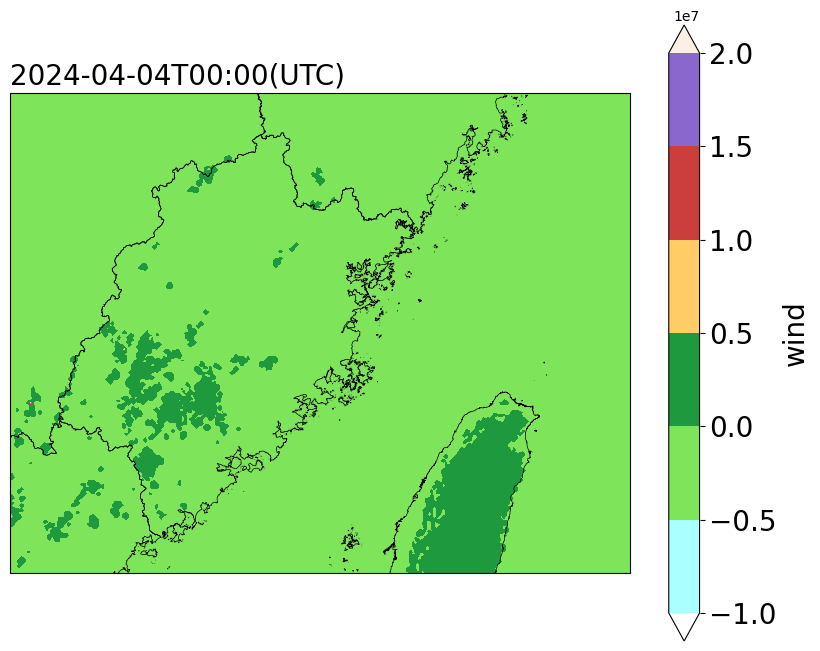

In [6]:
###方法一###
###方法一###
###方法一###
###方法一###
# 提取WRF模拟的经纬度数组
lats, lons = latlon_coords(t)

# 提取WRF模拟的地图投影
wrf_proj = get_cartopy(t)
# 创建画布
fig = plt.figure(figsize=(10, 8))
# 设置地图投影
ax = plt.axes(projection=wrf_proj)
# 设置地图范围
ax.set_xlim(cartopy_xlim(t))
ax.set_ylim(cartopy_ylim(t))

# 读取shp
province = shpreader.Reader(
    "E:/0_ditudate/矢量图/和鲸矢量图/province_9south.shp")

# 绘制国界线和九段线
ax.add_geometries(province.geometries(),
                  crs=ccrs.PlateCarree(),
                  linewidth=0.5,
                  edgecolor='k',
                  facecolor='none',
                  zorder=2)

# 绘制分布（用contourf方法实现等值线填充）
plt.contourf(to_np(lons),
             to_np(lats),
             to_np(we1),
             extend='both',
             transform=ccrs.PlateCarree(),
             cmap=cmaps.prcp_1)
# 添加colorbar
cbar = plt.colorbar(ax=ax, extend='both', shrink=1)
cbar.set_label('wind', fontdict={'size': 20})
cbar.ax.tick_params(labelsize=20)

# 设置刻度标签的字体大小
plt.tick_params(labelsize=15)
# 添加标题
plt.title(str(u.Time.values)[0:16]+'(UTC)', loc='left', fontsize=20)
plt.show()

In [7]:
gmp1 = z - hgt
we2 = interplevel(we, gmp1 ,100)
we2

<xarray.DataArray 'None_interp' (south_north: 207, west_east: 267)> Size: 221kB
array([[-8.71666504e+02, -3.35534180e+02, -3.43429108e+02, ...,
        -1.14668602e+05, -1.11926117e+05, -1.09458852e+05],
       [-4.44196716e+02, -4.36479828e+02, -6.60678406e+02, ...,
        -1.16695055e+05, -1.14131867e+05, -1.11895242e+05],
       [-3.56466736e+02, -7.14962769e+02, -2.19714355e+03, ...,
        -1.18557211e+05, -1.16179133e+05, -1.14156273e+05],
       ...,
       [-6.89820023e+01, -1.63936386e+02, -2.10118713e+02, ...,
        -3.81326294e+03, -3.82342041e+03, -3.84334766e+03],
       [-4.40224648e+01, -4.95111198e+01, -5.97477608e+01, ...,
        -3.70459253e+03, -3.71196826e+03, -3.72709619e+03],
       [-5.39698906e+01, -4.75726662e+01, -4.73574905e+01, ...,
        -3.62431812e+03, -3.62881226e+03, -3.63818628e+03]], dtype=float32)
Coordinates:
    XLONG      (south_north, west_east) float32 221kB 115.3 115.3 ... 123.3
    XLAT       (south_north, west_east) float32 221kB 23.17 23.17 ... 28.72
    XTIME      float32 4B 0.0
    Time       datetime64[ns] 8B 2024-04-04
    wspd_wdir  <U4 16B 'wspd'
    level      int32 4B 100
Dimensions without coordinates: south_north, west_east
Attributes:
    missing_value:  9.969209968386869e+36
    _FillValue:     9.969209968386869e+36
    vert_units:     None

ValueError: A colormap named "prcp_1" is already registered.

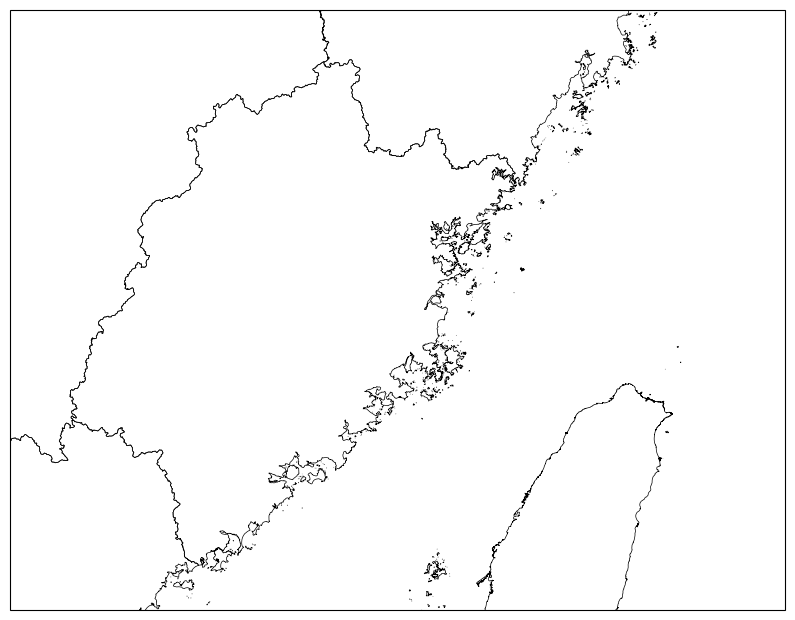

In [8]:
###方法二###
###方法二###
###方法二###
###方法二###
# 提取WRF模拟的经纬度数组
lats, lons = latlon_coords(t)

# 提取WRF模拟的地图投影
wrf_proj = get_cartopy(t)
# 创建画布
fig = plt.figure(figsize=(10, 8))
# 设置地图投影
ax = plt.axes(projection=wrf_proj)
# 设置地图范围
ax.set_xlim(cartopy_xlim(t))
ax.set_ylim(cartopy_ylim(t))

# 读取shp
province = shpreader.Reader(
    "E:/0_ditudate/矢量图/和鲸矢量图/province_9south.shp")

# 绘制国界线和九段线
ax.add_geometries(province.geometries(),
                  crs=ccrs.PlateCarree(),
                  linewidth=0.5,
                  edgecolor='k',
                  facecolor='none',
                  zorder=2)
# 绘制分布（用contourf方法实现等值线填充）
plt.contourf(to_np(lons),
             to_np(lats),
             to_np(we2),
             extend='both',
             transform=ccrs.PlateCarree(),
             cmap=cmaps.prcp_1)
# 添加colorbar
cbar = plt.colorbar(ax=ax, extend='both', shrink=1)
cbar.set_label('wind', fontdict={'size': 20})
cbar.ax.tick_params(labelsize=20)

# 设置刻度标签的字体大小
plt.tick_params(labelsize=15)
# 添加标题
plt.title(str(u.Time.values)[0:16]+'(UTC)', loc='left', fontsize=20)
plt.show()